# 视网膜血管分割与生物标志物提取演示

这个 Notebook 展示了一个完整的视网膜图像分析流程，旨在支持与“视网膜微血管生物标志物”相关的博士研究项目。

**流程概览:**
1.  **数据集加载**: 从DRIVE数据集中加载样本，包括原始图像和专家手动标注的分割真值。
2.  **模型预测**: 使用预训练的 U-Net (ResNet18 backbone) 模型对视网膜图像进行血管分割。
3.  **结果可视化**: 直观地展示分割结果，包括与真值的对比以及在原始图像上的叠加可视化。
4.  **生物标志物提取**: 从分割出的血管掩码中计算关键的生物标志物，如血管密度和骨架长度。

### 前置步骤: 导入必要的库和我们自己的模块

在开始之前，我们首先导入所有需要的库，包括 PyTorch、OpenCV、Matplotlib，以及我们为这个项目编写的 `data_loader`, `model`, 和 `utils` 模块。

In [6]:
import os
import torch
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# 确保我们的模块可以被导入
import sys
# 将当前目录添加到Python路径中
# 在Jupyter中，通常不需要这一步，但为了稳健性加上
if '.' not in sys.path:
    sys.path.append('.')

# 导入我们自己的模块
from data_loader import DRIVEDataset, get_transforms
from model import build_model
from utils import unnormalize_image, calculate_biomarkers

# 忽略一些不影响结果的警告
import warnings
warnings.filterwarnings('ignore')

print("所有库和模块已成功导入！")

所有库和模块已成功导入！


### 步骤 1: 配置和加载模型

我们需要指定数据集和模型输出的路径，然后加载我们之前训练好的最佳模型。脚本会自动查找最新的模型文件。

In [10]:
# --- 配置 ---
DRIVE_DIR = r'segmentation\datasets\drive-retina-dataset-master'
OUTPUTS_DIR = r'segmentation\outputs'
IMAGE_SIZE = 480

# --- 自动查找最新模型 ---
def get_latest_model_path(output_dir):
    try:
        subdirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]
        if not subdirs: return None
        latest_dir = sorted(subdirs)[-1]
        model_path = os.path.join(output_dir, latest_dir, 'best_model.pth')
        return model_path if os.path.exists(model_path) else None
    except FileNotFoundError:
        return None

MODEL_PATH = get_latest_model_path(OUTPUTS_DIR)
if not MODEL_PATH:
    raise FileNotFoundError(f"在 '{OUTPUTS_DIR}' 中找不到任何模型，请先运行 train_model.py")

print(f"将使用的模型: {MODEL_PATH}")

# --- 加载模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print(f"模型已加载到设备: {device}")


将使用的模型: D:\Zephyr\Documents\SVNResources\retinal\segmentation\outputs\20260307-230417\best_model.pth
模型已加载到设备: cpu


### 步骤 2: 数据集样本展示

我们从DRIVE测试集中加载一张样本图像，并展示它的原始外观和对应的“金标准”（Ground Truth）手动分割掩码。

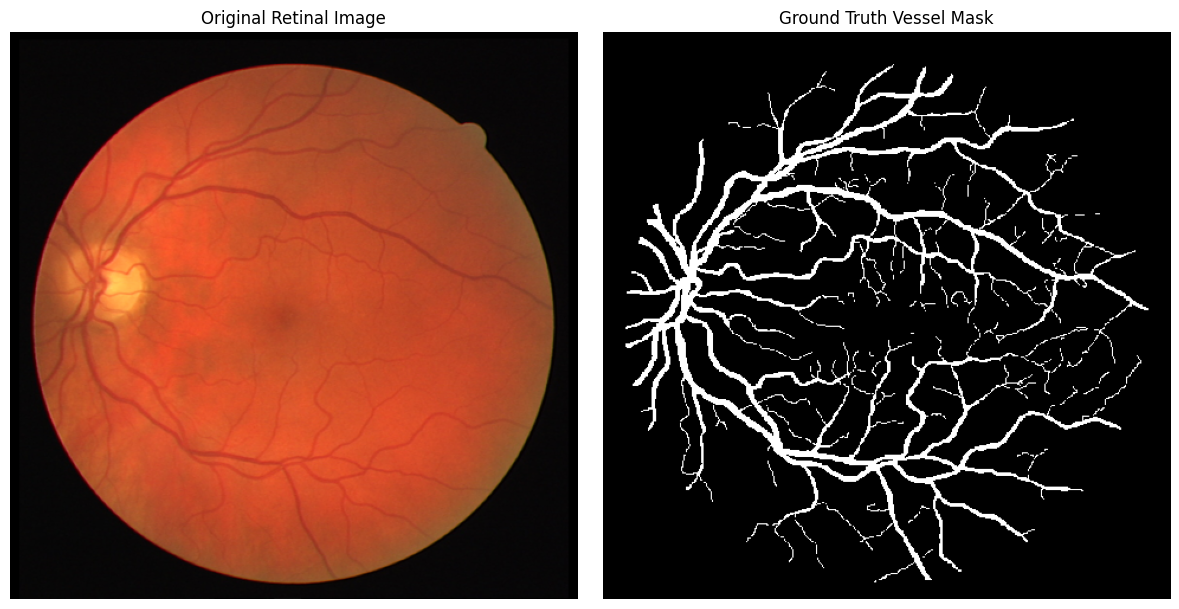

In [11]:
# --- 加载数据 ---
# 我们只加载一张图片用于演示
transforms = get_transforms(IMAGE_SIZE)
test_dataset = DRIVEDataset(root_dir=DRIVE_DIR, transform=transforms, subset='test')
# 从测试集中选择一个样本，例如第5张图片 (索引为4)
sample_idx = 4
sample = test_dataset[sample_idx]

# 将Tensor转为可显示的Numpy数组
original_img_np = unnormalize_image(sample['image'].cpu())
gt_mask_np = sample['mask'].squeeze().cpu().numpy()

# --- 可视化 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_img_np)
axes[0].set_title('Original Retinal Image')
axes[0].axis('off')

axes[1].imshow(gt_mask_np, cmap='gray')
axes[1].set_title('Ground Truth Vessel Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 步骤 3: 血管分割与结果可视化

现在，我们将加载的样本图像输入到U-Net模型中，得到预测的血管掩码。然后，我们将输入图像、真值掩码和预测掩码并排展示，以直观地评估分割效果。

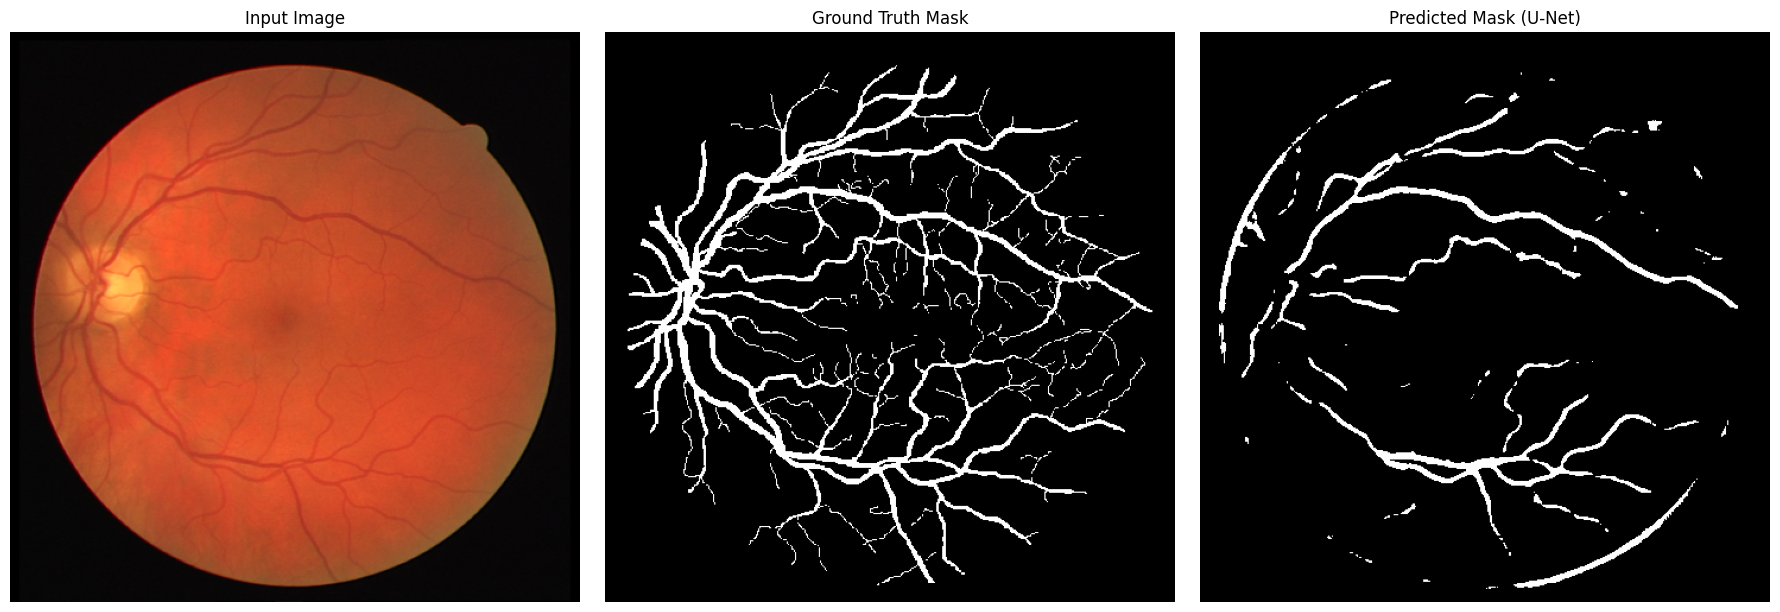

In [12]:
# --- 模型预测 ---
input_tensor = sample['image'].unsqueeze(0).to(device) # 增加一个batch维度并移动到设备
with torch.no_grad():
    pred_tensor = model(input_tensor)

# 将预测结果从Tensor转为Numpy数组，并进行二值化处理
pred_mask_np = (pred_tensor.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

# --- 三图对比可视化 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].imshow(gt_mask_np, cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(pred_mask_np, cmap='gray')
axes[2].set_title('Predicted Mask (U-Net)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#### 叠加可视化 (Overlay Visualization)
我们将预测出的血管（红色）叠加在原始视网膜图像上，可以非常直观地看出分割的准确性。

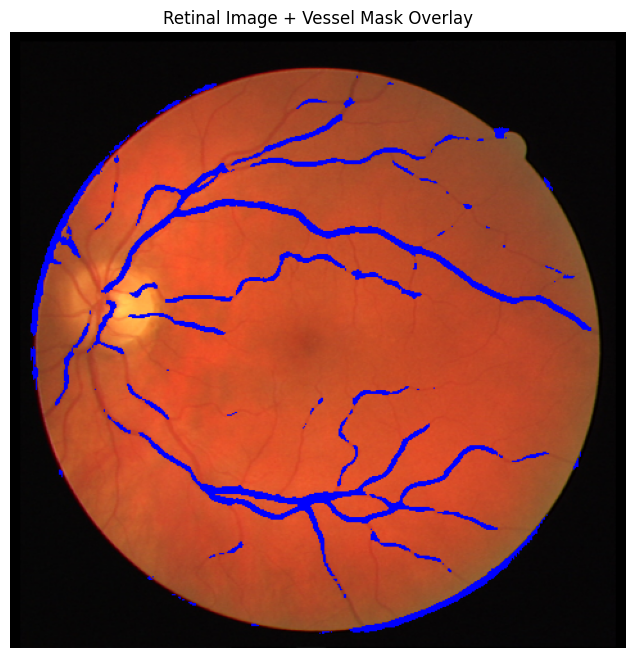

In [14]:
# --- 创建叠加图像 ---
overlay_img = (original_img_np * 255).astype(np.uint8).copy()
# 将预测为血管的像素点设置为蓝色 [0, 0, 255]
overlay_img[pred_mask_np == 1] = [0, 0, 255]

# --- 可视化 ---
plt.figure(figsize=(8, 8))
plt.imshow(overlay_img)
plt.title('Retinal Image + Vessel Mask Overlay')
plt.axis('off')
plt.show()


### 步骤 4: 生物标志物提取 (Biomarker Extraction)

这是项目的核心，完全对应博士申请的研究方向。我们遵循以下流程，从原始图像一步步提取出量化指标：

**Input Retinal Image → Vessel Segmentation → Binary Vessel Mask → Skeletonization → Biomarker Extraction**

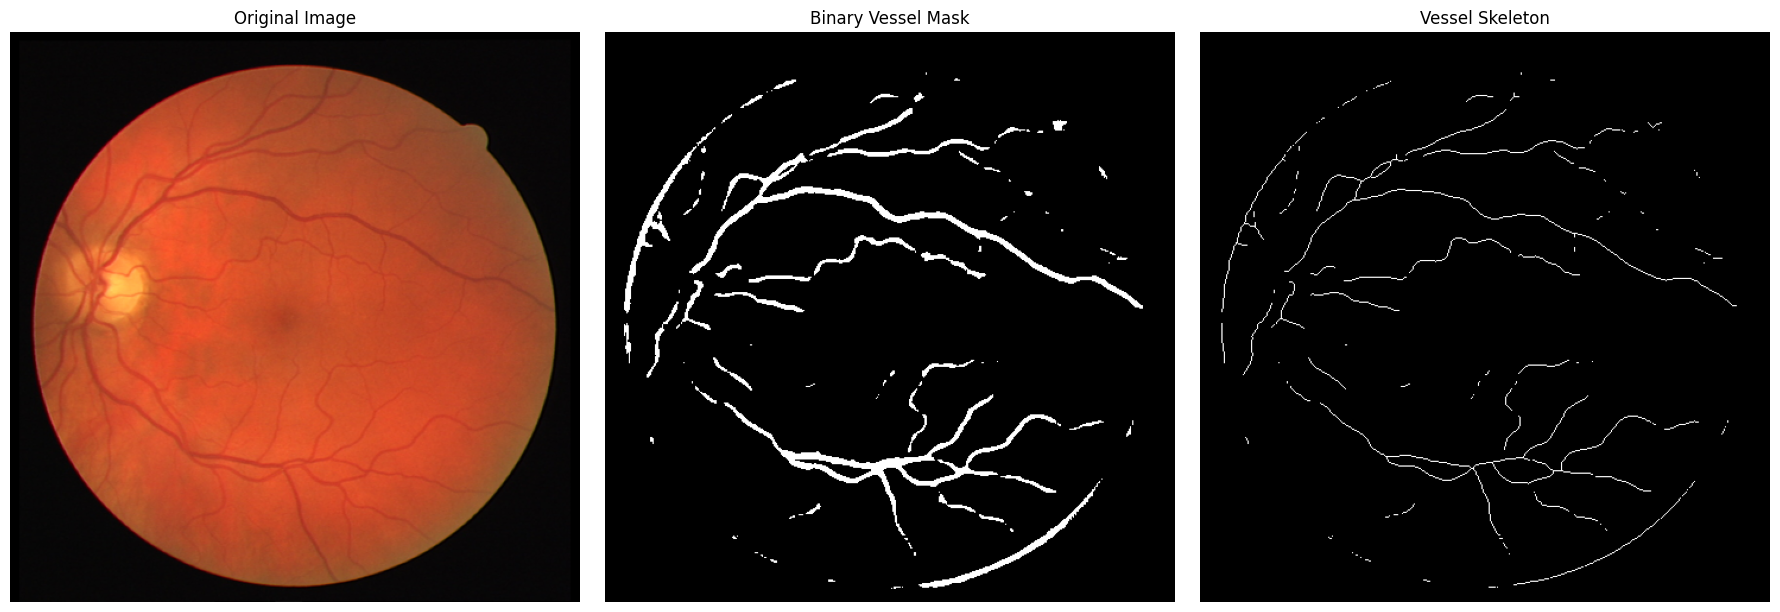

提取的生物标志物 (Biomarkers):
  - 血管密度 (Vessel Density): 0.0645
  - 血管骨架总长度 (Skeleton Length): 2724 pixels


In [15]:
# --- 1. 获取二值化掩码 (已在步骤3完成) ---
binary_mask = pred_mask_np

# --- 2. 骨架化 (Skeletonization) ---
# 我们需要在视野范围 (Field of View, FOV) 内进行骨架化，以排除图像边缘的噪声
fov_mask_np = (sample['fov_mask'].squeeze().cpu().numpy() > 0.5).astype(np.uint8)
skeleton = skeletonize(binary_mask * fov_mask_np)

# --- 3. 可视化特征提取过程 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title('Binary Vessel Mask')
axes[1].axis('off')

axes[2].imshow(skeleton, cmap='gray')
axes[2].set_title('Vessel Skeleton')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# --- 4. 提取并输出生物标志物 ---
biomarkers = calculate_biomarkers(binary_mask, fov_mask_np)

print("="*40)
print("提取的生物标志物 (Biomarkers):")
print(f"  - 血管密度 (Vessel Density): {biomarkers['vessel_density']:.4f}")
print(f"  - 血管骨架总长度 (Skeleton Length): {biomarkers['skeleton_length']} pixels")
print("="*40)